<a href="https://colab.research.google.com/github/vlayushi407-glitch/ml-lab/blob/main/exp2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

In [3]:
#Load dataset

In [5]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"
data = pd.read_csv(url)

In [6]:
#select required columns
data = data[['mpg','displacement']]
data.dropna(inplace=True)

In [7]:
#print(data.head())

    mpg  displacement
0  18.0         307.0
1  15.0         350.0
2  18.0         318.0
3  16.0         304.0
4  17.0         302.0


In [12]:
# Features and target
X = data[['displacement']]
y = data['mpg']

#Train-test split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [14]:
#Linear Regression
linear_model = LinearRegression()
linear_model.fit(X_train,y_train)
y_pred_linear = linear_model.predict(X_test)
print("Linear Regression")
print("MSE=",mean_squared_error(y_test,y_pred_linear))
print("R2=",r2_score(y_test,y_pred_linear))

Linear Regression
MSE= 18.102543998358946
R2= 0.6633114869465596


In [17]:
degree = [2,3,4]
for degree in degree:
  poly = PolynomialFeatures(degree)
  X_train_poly = poly.fit_transform(X_train)
  X_test_poly = poly.transform(X_test)
  model = LinearRegression()
  model.fit(X_train_poly,y_train)
  y_pred_poly = model.predict(X_test_poly)
  print("\nDegree=",degree)
  print("MSE=",mean_squared_error(y_test,y_pred_poly))
  print("R2=",r2_score(y_test,y_pred_poly))


Degree= 2
MSE= 15.10735356108076
R2= 0.7190189176110284

Degree= 3
MSE= 14.943631793037289
R2= 0.722063972418907

Degree= 4
MSE= 14.961486893912738
R2= 0.7217318860908903


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


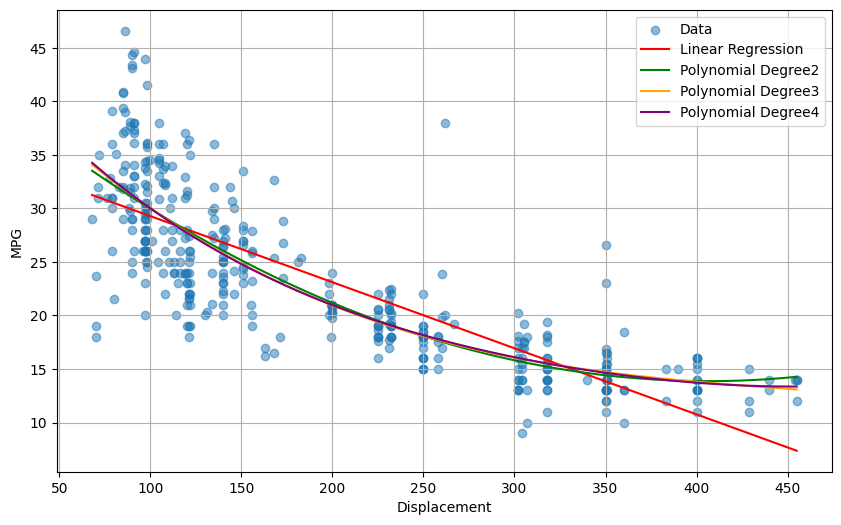

In [27]:
#visualization
X_range = np.linspace(X.min(),X.max(),300).reshape(-1,1)
plt.figure(figsize=(10,6))
plt.scatter(X,y,alpha=0.5,label='Data')
plt.plot(X_range,linear_model.predict(X_range),color='red',label='Linear Regression')
colors=['green','orange','purple']
for degree,color in zip([2,3,4],colors):
  poly=PolynomialFeatures(degree)
  X_poly=poly.fit_transform(X)
  model=LinearRegression()
  model.fit(X_poly,y)
  plt.plot(X_range,model.predict(poly.transform(X_range)),color=color,label=f'Polynomial Degree{degree}')
  plt.xlabel("Displacement")
  plt.ylabel("MPG")
plt.legend()
plt.grid()
plt.show()